In [ ]:
HIMMI Fatima (GLCC)

In [52]:
import numpy as np  # j'utilise numpy pour manipuler les tableaux et faire des calculs

import matplotlib.pyplot as plt  # pour tracer des graphes et visualiser les résultats

from sklearn.linear_model import LinearRegression, LogisticRegression  
from sklearn.preprocessing import PolynomialFeatures  
# pour transformer les données et ajouter des termes polynomiaux 

In [39]:
# X représente la variable indépendante (input)
# Ici : le kilométrage des voitures
X = np.array([5000, 10000, 20000, 30000, 40000, 50000]).reshape(-1,1)
# reshape(-1,1) transforme le tableau en matrice colonne (format exigé en ML)

# y représente la variable dépendante (output)
# Ici : le prix des voitures
y = np.array([30000, 28000, 25000, 22000, 20000, 18000])

In [40]:
# Ajouter une colonne de 1 (biais)
X_b = np.c_[np.ones((len(X), 1)), X]

# Calcul des coefficients avec la formule mathématique
theta = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

# Prédictions
y_pred = X_b.dot(theta)

# Affichage des paramètres (b0, b1)
print(theta)

[ 3.06986301e+04 -2.65753425e-01]


In [41]:
# Créer le modèle de régression linéaire
model = LinearRegression()

# Entraîner le modèle sur les données (apprendre les coefficients)
model.fit(X, y)

# Afficher les paramètres du modèle
# intercept_ = b0 (ordonnée à l'origine)
# coef_ = b1 (pente)
print(model.intercept_, model.coef_)

30698.6301369863 [-0.26575342]


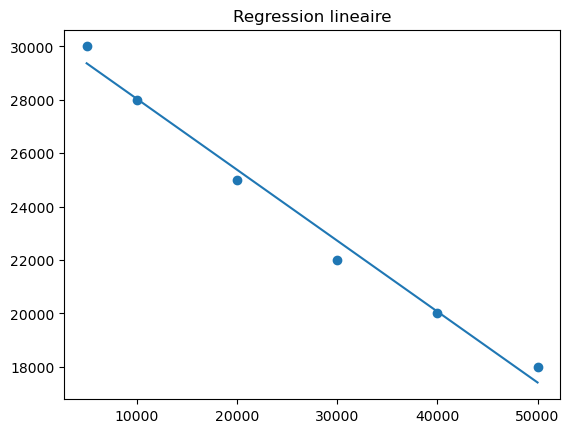

In [42]:
# j’affiche les points réels 
plt.scatter(X, y)

# j’affiche la droite de régression (les prédictions)
plt.plot(X, y_pred)

plt.title("Regression lineaire")
plt.show()

In [43]:
# ici j’ai deux variables : kilométrage et âge
X_multi = np.array([
    [5000, 5],
    [10000, 4],
    [20000, 3],
    [30000, 2],
    [40000, 2],
    [50000, 1]
])

# y_multi représente le prix correspondant
y_multi = np.array([30000, 28000, 25000, 22000, 20000, 18000])

# j’ajoute une colonne de 1 pour le biais (intercept)
X_b = np.c_[np.ones((len(X_multi), 1)), X_multi]

# je calcule les coefficients du modèle (b0, b1, b2)
theta_multi = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y_multi)

# j’affiche les coefficients trouvés
print(theta_multi)


# ici j’ai deux variables : kilométrage et âge
X_multi = np.array([
    [5000, 5],
    [10000, 4],
    [20000, 3],
    [30000, 2],
    [40000, 2],
    [50000, 1]
])

# y_multi représente le prix correspondant
y_multi = np.array([30000, 28000, 25000, 22000, 20000, 18000])

# j’ajoute une colonne de 1 pour le biais (intercept)
X_b = np.c_[np.ones((len(X_multi), 1)), X_multi]

# je calcule les coefficients du modèle (b0, b1, b2)
theta_multi = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y_multi)

# j’affiche les coefficients trouvés
print(theta_multi)

[ 2.47637795e+04 -1.67716535e-01  1.20078740e+03]
[ 2.47637795e+04 -1.67716535e-01  1.20078740e+03]


In [44]:
# je crée un modèle de régression linéaire
model = LinearRegression()

# j’entraîne le modèle avec plusieurs variables (kilométrage et âge)
model.fit(X_multi, y_multi)

# j’affiche les coefficients de chaque variable
print(model.coef_)

[-1.67716535e-01  1.20078740e+03]


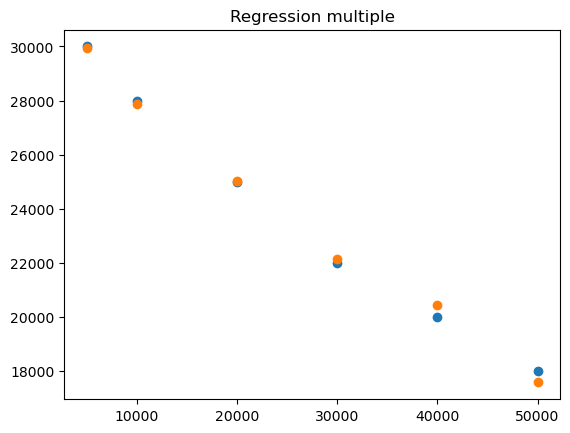

In [45]:
# je calcule les valeurs prédites avec le modèle multiple
y_pred_multi = X_b.dot(theta_multi)

# j’affiche les données réelles (prix)
plt.scatter(X_multi[:,0], y_multi)

# j’affiche les valeurs prédites par le modèle
plt.scatter(X_multi[:,0], y_pred_multi)

plt.title("Regression multiple")
plt.show()

In [46]:
# ici je crée des variables polynomiales (x et x²) pour capturer une relation non linéaire
X_poly = np.c_[X, X**2]

# j’ajoute une colonne de 1 pour le biais (intercept)
X_b = np.c_[np.ones((len(X_poly), 1)), X_poly]

# je calcule les coefficients du modèle (b0, b1, b2)
theta_poly = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

# je fais les prédictions avec ce modèle
y_pred_poly = X_b.dot(theta_poly)

# j’affiche les coefficients trouvés
print(theta_poly)

[ 3.18361995e+04 -3.94482660e-01  2.37603898e-06]


In [47]:
# je crée des variables polynomiales (x et x² automatiquement)
poly = PolynomialFeatures(degree=2)

# fit_transform transforme X en [1, x, x²]
X_poly2 = poly.fit_transform(X)

# je crée un modèle de régression linéaire
model = LinearRegression()

# j’entraîne le modèle avec ces nouvelles variables
model.fit(X_poly2, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


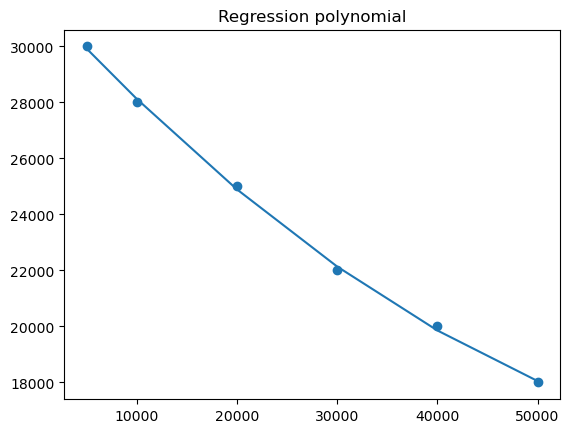

In [48]:
# je trie les valeurs de X pour obtenir une courbe bien tracée
sorted_idx = X.flatten().argsort()
X_sorted = X[sorted_idx]

# je recrée les variables polynomiales (x et x²)
X_poly_sorted = np.c_[X_sorted, X_sorted**2]

# j’ajoute le biais
X_b_sorted = np.c_[np.ones((len(X_poly_sorted), 1)), X_poly_sorted]

# je calcule les prédictions du modèle
y_sorted_pred = X_b_sorted.dot(theta_poly)

# affichage des données réelles et de la courbe polynomiale
plt.scatter(X, y)
plt.plot(X_sorted, y_sorted_pred)
plt.title("Regression polynomial")
plt.show()

In [49]:
# ici je transforme le problème en classification (1 = cher, 0 = pas cher)
y_class = np.array([1, 1, 1, 0, 0, 0])

# fonction sigmoid pour transformer en probabilités (entre 0 et 1)
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# j’ajoute une colonne de 1 pour le biais
X_b = np.c_[np.ones((len(X), 1)), X]

# j’initialise les paramètres à 0
theta_log = np.zeros(X_b.shape[1])

# j’utilise le gradient descent pour apprendre les paramètres
for i in range(1000):
    z = X_b.dot(theta_log)   # combinaison linéaire
    h = sigmoid(z)           # probabilité
    
    # calcul de l’erreur (gradient)
    gradient = X_b.T.dot(h - y_class) / len(y_class)
    
    # mise à jour des paramètres
    theta_log -= 0.000000001 * gradient

# affichage des paramètres
print(theta_log)

[ 2.03701306e-07 -3.63494414e-05]


In [50]:
# je crée un modèle de régression logistique
model = LogisticRegression()

# j’entraîne le modèle avec les données (X et y_class)
model.fit(X, y_class)

# je fais les prédictions (0 ou 1)
y_pred_class = model.predict(X)

# j’affiche les résultats
print(y_pred_class)

[1 1 1 0 0 0]


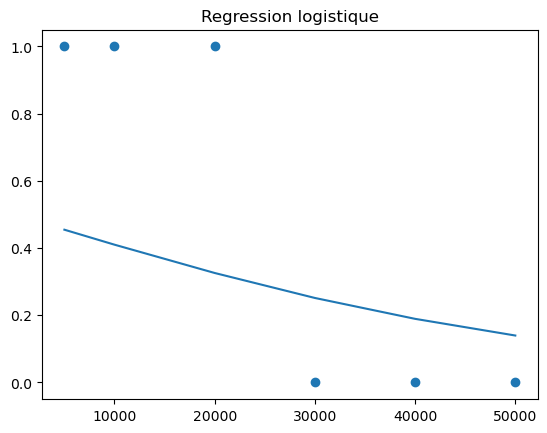

In [51]:
# je calcule z (combinaison linéaire avec les paramètres appris)
z = X_b.dot(theta_log)

# je transforme z en probabilités avec la fonction sigmoid
y_prob = sigmoid(z)

# j’affiche les points réels (0 ou 1)
plt.scatter(X, y_class)

# j’affiche la courbe de probabilité (sigmoid)
plt.plot(X, y_prob)

plt.title("Regression logistique")
plt.show()